In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install paddlepaddle -i https://pypi.tuna.tsinghua.edu.cn/simple
!pip install "paddleocr>=2.0.1"

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 MB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: opt-einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.4 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=910cc40e9

In [ ]:
!pip install python-doctr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 31.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.1/304.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 59.4 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=b3af3f352b78391c633d9e3b20f75900138de307ab28ce929787d892e4fde34f
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


PADDLEOCR WORKING


In [ ]:
import os
import time
import pandas as pd
from paddleocr import PaddleOCR

# Initialize PaddleOCR
print("Initializing PaddleOCR...")
ocr = PaddleOCR(use_angle_cls=True, lang='en', use_gpu=False)
print("PaddleOCR initialized.")

def extract_text_from_image(image_path):
    try:
        result = ocr.ocr(image_path, cls=True)
        if result is None or len(result) == 0:
            return ""

        extracted_text = []
        for line in result:
            line_text = ' '.join([word_info[1][0] for word_info in line])
            extracted_text.append(line_text)
        return ' '.join(extracted_text)
    except Exception as e:
        print(f"Error in OCR processing: {str(e)}")
        return ""

from difflib import SequenceMatcher

def calculate_metrics(extracted_text, reference_text):
    similarity = SequenceMatcher(None, extracted_text.lower(), reference_text.lower()).ratio()

    precision = similarity
    recall = similarity
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }


# Directories
image_dir = r'/content/drive/MyDrive/Testing/testing_words'
csv_path = r'/content/drive/MyDrive/Testing/testing_labels.csv'

# Load CSV
df = pd.read_csv(csv_path)
if 'IMAGE' not in df.columns or 'MEDICINE_NAME' not in df.columns:
    raise ValueError("Le fichier CSV ne contient pas les colonnes attendues: IMAGE, MEDICINE_NAME")

# Variables to track metrics
total_precision = 0.0
total_recall = 0.0
total_f1 = 0.0
num_files = 0
total_execution_time = 0.0

# Store results for each file
results = []

print("\nStarting OCR evaluation...")
print("="*50)
for index, row in df.iterrows():
    image_filename = row['IMAGE']
    reference_text = str(row['MEDICINE_NAME'])
    image_path = os.path.join(image_dir, image_filename)

    if os.path.exists(image_path):
        try:
            print(f"\nProcessing {image_filename}...")
            start_time = time.time()

            extracted_text = extract_text_from_image(image_path)
            metrics = calculate_metrics(extracted_text, reference_text)

            total_precision += metrics['precision']
            total_recall += metrics['recall']
            total_f1 += metrics['f1_score']
            num_files += 1
            execution_time = time.time() - start_time

            results.append({
                'filename': image_filename,
                'metrics': metrics,
                'execution_time': execution_time
            })

            print(f"Results for {image_filename}:")
            print(f"Reference: {reference_text}")
            print(f"Extracted: {extracted_text}")
            print(f"Precision: {metrics['precision']:.2f}")
            print(f"Recall: {metrics['recall']:.2f}")
            print(f"F1 Score: {metrics['f1_score']:.2f}")
            print(f"Execution Time: {execution_time:.2f} seconds")
        except Exception as e:
            print(f"Error processing {image_filename}: {str(e)}")
    else:
        print(f"Image file not found: {image_filename}")

# Calculate and output the averages
if num_files > 0:
    average_precision = total_precision / num_files
    average_recall = total_recall / num_files
    average_f1 = total_f1 / num_files
    average_execution_time = sum(r['execution_time'] for r in results) / num_files

    print("\n" + "="*50)
    print("SUMMARY STATISTICS FOR PADDLEOCR:")
    print("="*50)
    print(f"Number of files processed: {num_files}")
    print(f"Average Precision: {average_precision:.2f}")
    print(f"Average Recall: {average_recall:.2f}")
    print(f"Average F1 Score: {average_f1:.2f}")
    print(f"Average Execution Time: {average_execution_time:.2f} seconds per image")
else:
    print("No images were processed.")


Streaming output truncated to the last 5000 lines.

Processing 374.png...
[2025/03/11 15:46:47] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.0602107048034668
[2025/03/11 15:46:47] ppocr DEBUG: cls num  : 0, elapsed : 0
[2025/03/11 15:46:47] ppocr DEBUG: rec_res num  : 0, elapsed : 2.86102294921875e-06
Error in OCR processing: 'NoneType' object is not iterable
Results for 374.png:
Reference: Flugal
Extracted: 
Precision: 0.00
Recall: 0.00
F1 Score: 0.00
Execution Time: 0.07 seconds

Processing 375.png...
[2025/03/11 15:46:47] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.016643047332763672
[2025/03/11 15:46:47] ppocr DEBUG: cls num  : 1, elapsed : 0.013583183288574219
[2025/03/11 15:46:47] ppocr DEBUG: rec_res num  : 1, elapsed : 0.07475161552429199
Results for 375.png:
Reference: Flugal
Extracted: Fluga
Precision: 0.91
Recall: 0.91
F1 Score: 0.91
Execution Time: 0.11 seconds

Processing 376.png...
[2025/03/11 15:46:47] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.06653404235839844
[2025/03/11

TrOCR WORKING

In [ ]:
import os
import time
import base64
import pandas as pd
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from difflib import SequenceMatcher
import re

# Initialize TrOCR
print("Initializing TrOCR...")
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
print("TrOCR initialized.")

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

def extract_text_from_image(image_path):
    try:
        image = Image.open(image_path).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values
        generated_ids = model.generate(pixel_values)
        return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    except Exception as e:
        print(f"Error in OCR processing: {str(e)}")
        return ""

def calculate_metrics(extracted_text, reference_text):
    normalized_extracted = normalize_text(extracted_text)
    normalized_reference = normalize_text(reference_text)
    similarity = SequenceMatcher(None, normalized_extracted, normalized_reference).ratio()
    return {
        'precision': similarity,
        'recall': similarity,
        'f1_score': similarity,
    }

# Directories
image_dir = r'/content/drive/MyDrive/Testing/testing_words'
csv_path = r'/content/drive/MyDrive/Testing/testing_labels.csv'

# Load CSV
df = pd.read_csv(csv_path)
if 'IMAGE' not in df.columns or 'MEDICINE_NAME' not in df.columns:
    raise ValueError("Le fichier CSV ne contient pas les colonnes attendues: IMAGE, MEDICINE_NAME")

# Variables to track metrics
total_precision = 0.0
total_recall = 0.0
total_f1 = 0.0
num_files = 0
total_execution_time = 0.0

# Store results for each file
results = []

print("\nStarting OCR evaluation...")
print("="*50)
for index, row in df.iterrows():
    image_filename = row['IMAGE']
    reference_text = str(row['MEDICINE_NAME'])
    image_path = os.path.join(image_dir, image_filename)

    if os.path.exists(image_path):
        try:
            print(f"\nProcessing {image_filename}...")
            start_time = time.time()

            extracted_text = extract_text_from_image(image_path)
            metrics = calculate_metrics(extracted_text, reference_text)

            total_precision += metrics['precision']
            total_recall += metrics['recall']
            total_f1 += metrics['f1_score']
            num_files += 1
            execution_time = time.time() - start_time

            results.append({
                'filename': image_filename,
                'metrics': metrics,
                'execution_time': execution_time
            })

            print(f"Results for {image_filename}:")
            print(f"Reference: {reference_text}")
            print(f"Extracted: {extracted_text}")
            print(f"Precision: {metrics['precision']:.2f}")
            print(f"Recall: {metrics['recall']:.2f}")
            print(f"F1 Score: {metrics['f1_score']:.2f}")
            print(f"Execution Time: {execution_time:.2f} seconds")
        except Exception as e:
            print(f"Error processing {image_filename}: {str(e)}")
    else:
        print(f"Image file not found: {image_filename}")

# Calculate and output the averages
if num_files > 0:
    average_precision = total_precision / num_files
    average_recall = total_recall / num_files
    average_f1 = total_f1 / num_files
    average_execution_time = sum(r['execution_time'] for r in results) / num_files

    print("\n" + "="*50)
    print("SUMMARY STATISTICS:")
    print("="*50)
    print(f"Number of files processed: {num_files}")
    print(f"Average Precision: {average_precision:.2f}")
    print(f"Average Recall: {average_recall:.2f}")
    print(f"Average F1 Score: {average_f1:.2f}")
    print(f"Average Execution Time: {average_execution_time:.2f} seconds per file")
else:
    print("No images were processed.")


Initializing TrOCR...


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

Streaming output truncated to the last 5000 lines.
Extracted: pitch .
Precision: 0.20
Recall: 0.20
F1 Score: 0.20
Execution Time: 4.78 seconds

Processing 226.png...
Results for 226.png:
Reference: Diflu
Extracted: difflin .
Precision: 0.67
Recall: 0.67
F1 Score: 0.67
Execution Time: 5.72 seconds

Processing 227.png...
Results for 227.png:
Reference: Diflu
Extracted: difflin .
Precision: 0.67
Recall: 0.67
F1 Score: 0.67
Execution Time: 4.82 seconds

Processing 228.png...
Results for 228.png:
Reference: Diflu
Extracted: 1 2 2million .
Precision: 0.24
Recall: 0.24
F1 Score: 0.24
Execution Time: 7.18 seconds

Processing 229.png...
Results for 229.png:
Reference: Diflu
Extracted: diffler .
Precision: 0.67
Recall: 0.67
F1 Score: 0.67
Execution Time: 4.66 seconds

Processing 230.png...
Results for 230.png:
Reference: Dinafex
Extracted: Dinofax .
Precision: 0.71
Recall: 0.71
F1 Score: 0.71
Execution Time: 5.27 seconds

Processing 231.png...
Results for 231.png:
Reference: Dinafex
Extracted: f

In [ ]:
!pip install easyocr pandas pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 940.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

EASYOCR WORKING

In [ ]:
import os
import time
import pandas as pd
import easyocr
from PIL import Image
from difflib import SequenceMatcher
import re

# Initialisation de EasyOCR
print("Initializing EasyOCR...")
reader = easyocr.Reader(['fr'], gpu=True)
print("EasyOCR initialized.")


def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def extract_text_from_image(image_path):
    try:
        results = reader.readtext(image_path, detail=0, paragraph=True)
        return ' '.join(results)
    except Exception as e:
        print(f"Error in OCR processing: {str(e)}")
        return ""


def calculate_metrics(extracted_text, reference_text):
    normalized_extracted = normalize_text(extracted_text)
    normalized_reference = normalize_text(reference_text)
    similarity = SequenceMatcher(None, normalized_extracted, normalized_reference).ratio()
    return {
        'precision': similarity,
        'recall': similarity,
        'f1_score': similarity,
    }


# Dossiers et fichiers
image_dir = r'/content/drive/MyDrive/Testing/testing_words'
csv_path = r'/content/drive/MyDrive/Testing/testing_labels.csv'

# Chargement du CSV
df = pd.read_csv(csv_path)
if 'IMAGE' not in df.columns or 'MEDICINE_NAME' not in df.columns:
    raise ValueError("Le fichier CSV ne contient pas les colonnes attendues: IMAGE, MEDICINE_NAME")

# Variables pour suivre les métriques
total_precision = 0.0
total_recall = 0.0
total_f1 = 0.0
num_files = 0
total_execution_time = 0.0

# Stockage des résultats
results = []

print("\nStarting OCR evaluation...")
print("="*50)

for index, row in df.iterrows():
    image_filename = row['IMAGE']
    reference_text = str(row['MEDICINE_NAME'])
    image_path = os.path.join(image_dir, image_filename)

    if os.path.exists(image_path):
        try:
            print(f"\nProcessing {image_filename}...")
            start_time = time.time()

            extracted_text = extract_text_from_image(image_path)
            metrics = calculate_metrics(extracted_text, reference_text)

            total_precision += metrics['precision']
            total_recall += metrics['recall']
            total_f1 += metrics['f1_score']
            num_files += 1
            execution_time = time.time() - start_time

            results.append({
                'filename': image_filename,
                'metrics': metrics,
                'execution_time': execution_time
            })

            print(f"Results for {image_filename}:")
            print(f"Reference: {reference_text}")
            print(f"Extracted: {extracted_text}")
            print(f"Precision: {metrics['precision']:.2f}")
            print(f"Recall: {metrics['recall']:.2f}")
            print(f"F1 Score: {metrics['f1_score']:.2f}")
            print(f"Execution Time: {execution_time:.2f} seconds")
        except Exception as e:
            print(f"Error processing {image_filename}: {str(e)}")
    else:
        print(f"Image file not found: {image_filename}")

# Calcul des moyennes
if num_files > 0:
    average_precision = total_precision / num_files
    average_recall = total_recall / num_files
    average_f1 = total_f1 / num_files
    average_execution_time = sum(r['execution_time'] for r in results) / num_files

    print("\n" + "="*50)
    print("SUMMARY STATISTICS:")
    print("="*50)
    print(f"Number of files processed: {num_files}")
    print(f"Average Precision: {average_precision:.2f}")
    print(f"Average Recall: {average_recall:.2f}")
    print(f"Average F1 Score: {average_f1:.2f}")
    print(f"Average Execution Time: {average_execution_time:.2f} seconds per file")
else:
    print("No images were processed.")


Initializing EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Streaming output truncated to the last 5000 lines.
Extracted: pigle
Precision: 0.40
Recall: 0.40
F1 Score: 0.40
Execution Time: 0.58 seconds

Processing 226.png...
Results for 226.png:
Reference: Diflu
Extracted: biBln
Precision: 0.40
Recall: 0.40
F1 Score: 0.40
Execution Time: 0.50 seconds

Processing 227.png...
Results for 227.png:
Reference: Diflu
Extracted: bi8l
Precision: 0.44
Recall: 0.44
F1 Score: 0.44
Execution Time: 0.92 seconds

Processing 228.png...
Results for 228.png:
Reference: Diflu
Extracted: Difl
Precision: 0.89
Recall: 0.89
F1 Score: 0.89
Execution Time: 0.64 seconds

Processing 229.png...
Results for 229.png:
Reference: Diflu
Extracted: bigl
Precision: 0.44
Recall: 0.44
F1 Score: 0.44
Execution Time: 0.50 seconds

Processing 230.png...
Results for 230.png:
Reference: Dinafex
Extracted: DinoRe
Precision: 0.62
Recall: 0.62
F1 Score: 0.62
Execution Time: 0.71 seconds

Processing 231.png...
Results for 231.png:
Reference: Dinafex
Extracted: Fixa
Precision: 0.36
Recall: 0

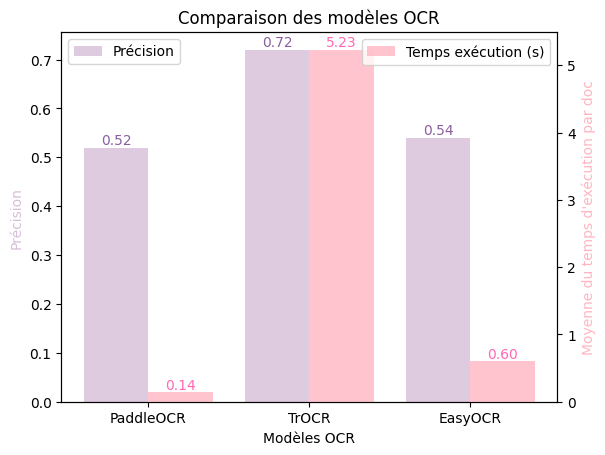

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Données des modèles OCR
models = ['PaddleOCR', 'TrOCR','EasyOCR']
precision = [0.52, 0.72,0.54]
execution_time = [0.14, 5.23, 0.60]

# Position des barres
x = np.arange(len(models))
width = 0.4

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, precision, width, label='Précision', color='#D8BFD8', alpha=0.8)
bars2 = ax2.bar(x + width/2, execution_time, width, label='Temps exécution (s)', color='#FFB6C1', alpha=0.8)

ax1.set_xlabel("Modèles OCR")
ax1.set_ylabel("Précision", color='#D8BFD8')
ax2.set_ylabel("Moyenne du temps d'exécution par doc", color='#FFB6C1')
ax1.set_title("Comparaison des modèles OCR")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

for bar in bars1:
    yval = bar.get_height()
    if yval > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', color='#8B5F9E')

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', color='#FF69B4')

plt.show()